In [1]:
import numpy as np
from scipy.sparse import spdiags, eye, kron
from scipy.sparse.linalg import spsolve, cg, LinearOperator
import scipy.sparse.linalg as splinalg
import matplotlib.pyplot as plt
import numba

In [2]:
def Amult(U, m):
    AU = np.pad(U.reshape((m, m)), ((1,1), (1,1)), 'constant')
    AU[1:-1, 1:-1] = \
        AU[:-2, 1:-1] + \
        AU[1:-1, :-2] + \
        AU[2:, 1:-1] + \
        AU[1:-1, 2:] - \
        4 * AU[1:-1, 1:-1] 
    return - (1+m)**2 * AU[1:-1, 1:-1].reshape(-1)

U = np.array([1,2,3,4])
m = 2
Amult(U, m)

array([-9, 27, 63, 99])

In [3]:
def u_func(x,y):
    return np.sin(4*np.pi*(x+y)) + np.cos(4*np.pi*x*y)

def f_func(x,y):
    term1 = -32*np.pi**2*np.sin(4*np.pi*(x+y))
    term2 = -16*np.pi**2*(x**2 + y**2)*np.cos(4*np.pi*x*y)
    return term1 + term2

def form_rhs(m, f_func, u_func):

    h = 1.0/(m+1)
    b = np.zeros(m*m)

    for j in range(1, m+1):
        for i in range(1, m+1):

            k = (j-1)*m + (i-1)
            x = i*h
            y = j*h

            b[k] = f_func(x,y)

            # left boundary
            if i == 1:
                b[k] -= u_func(0,y)/h**2

            # right boundary
            if i == m:
                b[k] -= u_func(1,y)/h**2

            # bottom boundary
            if j == 1:
                b[k] -= u_func(x,0)/h**2

            # top boundary
            if j == m:
                b[k] -= u_func(x,1)/h**2

    return b

Successful


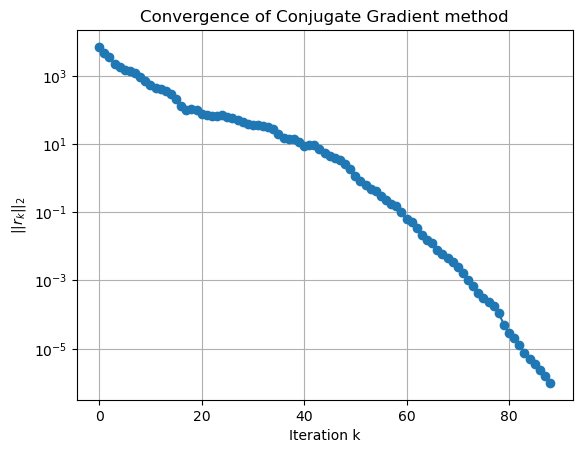

In [4]:

#ms = [3, 4, 10, 25, 50]
m = 25

errs = []


h = 1 / (m + 1)

F = form_rhs(m,f_func,u_func)
Aminus = LinearOperator(
    shape=(m**2, m**2), 
    matvec=lambda U: Amult(U, m),
    dtype=np.float64
)

residual_norms = []
def residual_norm(xk):
    r_norm = np.linalg.norm(F + Aminus @ xk)
    residual_norms.append(r_norm)

v, info = cg(Aminus, -F, rtol = 1e-10, callback = residual_norm)
print(f"{"Successful" if info == 0 else str(info) + " iterations"}")

plt.semilogy(residual_norms, 'o-')
plt.xlabel("Iteration k")
plt.ylabel(r"$||r_k||_2$")
plt.grid(True, which='both')
plt.title("Convergence of Conjugate Gradient method")
plt.show()

Relaxed iteration matrix:
$$
G_{\omega} = (1 - \omega) I + \omega G
$$

where OG iteration matrix in Jacobi iterations is
$$
G_J = I - D^{-1}A
$$
with $A$ is the system matrix for the discretized system.

Eigenvalues of iteration matrix $G$ from Leveque:
$$
\lambda_{p,q} = 
$$

For 30, min rho (rho = 0.3736) is at omega = 0.69388
For 60, min rho (rho = 0.3638) is at omega = 0.65306
For 200, min rho (rho = 0.3520) is at omega = 0.65306


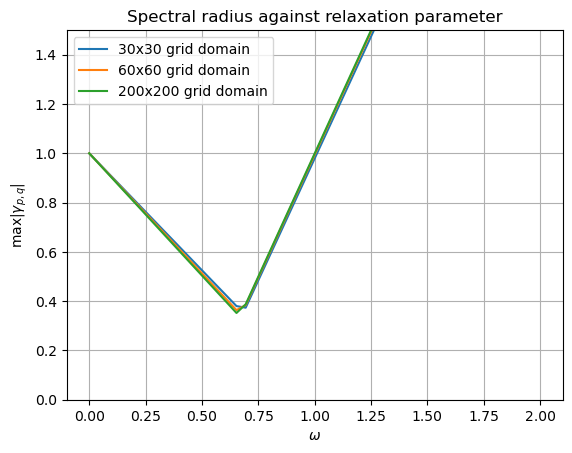

In [5]:
def eigen_part(h, p, q):
    # G = I - D**(-1) * A => lmb = 1 + h**2 / 4 (2 / h**2 * lmb(A))
    #                     => lmb = 1 + lmb(A)
    return 1 + 0.5 * (np.cos(p*np.pi*h) + np.cos(q*np.pi*h) - 2)


def gamma(eigen_part, omegas):
    shape_form = (*omegas.shape, *eigen_part.shape)
    g = np.empty(shape_form)
    for i,w in enumerate(omegas):
        g[i] = 1 - w + w * eigen_part

    return g


omega = np.linspace(0, 2, 50)
for m in [30, 60, 200]:
    h = 1 / (m + 1)
    p = np.arange(m//2, m)
    q = np.arange(m//2, m)
    P, Q = np.meshgrid(p, q)
    ep = eigen_part(h, P, Q)
    max_gamma_at_w = np.max(np.abs(gamma(ep, omega)), axis=(1,2))
    print(f"For {m}, min rho (rho = {np.min(max_gamma_at_w):.4f}) is at omega = {omega[np.argmin(max_gamma_at_w)]:.5f}")
    plt.plot(omega, max_gamma_at_w, label=f"{m}x{m} grid domain")

plt.xlabel(r'$\omega$')
plt.ylabel(r'$\max |\gamma_{p,q}|$')
plt.ylim(0, 1.5)
plt.grid()
plt.title('Spectral radius against relaxation parameter')
plt.legend()
plt.show()

# Recast ```Amult``` to return $A\mathbf U$ not $-A\mathbf U$

In [6]:
# LHS of a discretized Poisson problem
def Amult(U, m):
    h = 1.0 / (m + 1)
    AU = np.zeros_like(U)

    for j in range(m):
        for i in range(m):
            k = i + j*m   # 2D -> 1D index
            
            center = U[k]

            left = U[k-1] if i > 0 else 0.0
            right = U[k+1] if i < m - 1 else 0.0
            down = U[k-m] if j > 0 else 0.0
            up = U[k+m] if j < m - 1 else 0.0

            # Discrete Laplacian (Δ_h): (neighbors - 4*center)/h^2
            AU[k] = (left + right + down + up - 4 * center) / h**2

    return AU

# restriction and prolongation operations

In [7]:
from finite_diff_functions import smooth, l2_norm_grid

In [8]:
def coarsen(R, m):
    mc = m // 2
    Rc = np.empty(mc**2)

    # Half weighting
    for ic in range(mc):
        for jc in range(mc):
            kc = ic + jc*mc
            k = (2*ic + 1) + (2*jc + 1)*m

            center = R[k]
            left  = R[k-1] 
            right = R[k+1] 
            up  = R[k-m]   
            down    = R[k+m]
            
            Rc[kc] = 1 / 8 * (
                left # (i - 1, j)
                + up # (i, j - 1)
                + 4 * center # (i, j)
                + down # (i, j + 1)
                + right # (i + 1, j)
            )
    return Rc

In [9]:
def index_c_to_f(i,j):
    return (2*i + 1, 2*j + 1)

def scatter(Rc, m):
    mc = m // 2
    fine = np.zeros(m**2)
    fine.reshape(m,m)[1::2, 1::2] = Rc.reshape(mc, mc)
    for ic in range(mc):
        for jc in range(mc):
            i, j = index_c_to_f(ic, jc)
            # fine indexes
            n = i + (j-1) * m
            s = i + (j + 1) * m
            w = i - 1 + j*m
            e = i + 1 + j*m
            nw = i - 1 + (j-1) * m
            ne = i + 1 + (j-1) * m
            sw = i - 1 + (j+1) * m
            se = i + 1 + (j+1) * m
            corners = [nw, ne, sw, se]
            cross = [n, s, w, e]

            center_val = Rc[ic + jc*mc]
            fine[corners] += 1/4 * center_val
            fine[cross] += 1/2 * center_val
    return fine

# VCycle

In [10]:
def vcycle(A, R, P, u, f, l):
    '''
        # Parameters
            A: A matrix free operator computing discretized Poisson matrix-vector product A(u) = -A*u
            R: Function | (u, m) -> u with len(u) = m//2 Restriction operator coarsening the grid vectors to length m/2 x m/2
            P: Function | (u, m) -> u with len(u) = m**2 Prolongation operator interpolating grid vectors from length m/2 x m/2 -> m x m
            u: current guess at solution to Poisson problem
            f: RHS of discretized Poisson problem
            l: number of coarsening grid levels to traverse 
        # Output
            u: 
    '''
    if l == 1:
        # l = 1 ==> A^-1 = [-h**2/4] ==> u = u[0] = -h**2 / 4 * f[0]
        # l = 1 ==> h = 1/2
        #       ==> u = u[0] = -1/8 * f[0]
        u[0] = -1 / 16 * f[0]
    else:
        for _ in range(3): # nu_pre in algorithm
            u = smooth(u, 0.65306, 2**l - 1, f)
        
        # Residual for Δ_h u = f
        r = f - A(u, 2**l - 1)
        r = R(r, 2**l - 1)
        e = np.zeros_like(r)
        e = vcycle(A, R, P, e, r, l - 1)
        e = P(e, 2**l - 1)
        u += e
        
        for _ in range(3):
            u = smooth(u, 0.65306, 2**l - 1, f)
    
    return u

In [11]:
from finite_diff_functions import vec_smooth
m = 4
Ftest = form_rhs(m, f_func, u_func)
Utest = np.zeros(m**2, dtype=float)
for i in range(2):
    Utest = smooth(Utest, 2/3, m, Ftest)
    print(Utest)
print()
Utest = np.zeros(m**2, dtype=float)
for i in range(2):
    Utest = vec_smooth(Utest, 2/3, m, Ftest)
    print(Utest)

[-1.39939949  2.12344075 -0.88597365 -0.27297438  2.12344075 -1.38102861
 -0.54311738  0.59374197 -0.88597365 -0.54311738  1.09555868 -0.7727686
 -0.27297438  0.59374197 -0.7727686   1.28436165]
[-1.1580524   2.22018738 -0.9634067  -0.41267112  2.22018738 -1.31459702
 -0.8204401   0.5268459  -0.9634067  -0.8204401   1.02211625 -0.53474776
 -0.41267112  0.5268459  -0.53474776  1.45489266]

[-1.39939949  2.12344075 -0.88597365 -0.27297438  2.12344075 -1.38102861
 -0.54311738  0.59374197 -0.88597365 -0.54311738  1.09555868 -0.7727686
 -0.27297438  0.59374197 -0.7727686   1.28436165]
[-1.1580524   2.22018738 -0.9634067  -0.41267112  2.22018738 -1.31459702
 -0.8204401   0.5268459  -0.9634067  -0.8204401   1.02211625 -0.53474776
 -0.41267112  0.5268459  -0.53474776  1.45489266]


# Multigrid loop

m = 31


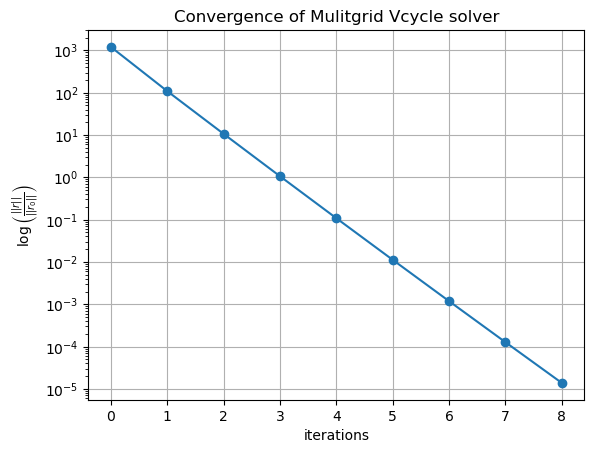

In [12]:
# multi grid loop
l = 5 # levels in V
m = 2**l - 1 # first number of interior points
print(f"m = {m}")
x = np.linspace(0, 1, m)
y = np.linspace(0,1, m)
X,Y = np.meshgrid(x, y, indexing='ij')
U0 = (1 + 2*X + 2*Y)
for ic in range(m):
    for jc in range(m):
        assert U0[ic,jc] - U0.flatten()[ic + jc*m] < 1e-15

U0 = U0.flatten()
F = form_rhs(m, f_func, u_func)
assert F.shape == U0.shape

kmax = 10

convergence_history = []

k = 0
rk = F - Amult(U0, m)  # residual r = f - Δ_h u
Uk = np.copy(U0)
EPS = 1e-4
for k in range(kmax):
    norm = l2_norm_grid(rk, 1/(m+1)) # h = 1/m+1
    convergence_history.append(norm)
    if norm < EPS: break

    Uk = vcycle(Amult, coarsen, scatter, Uk, F, l)
    rk = F - Amult(Uk, m)

plt.semilogy(convergence_history, '-o')
plt.xlabel('iterations')
plt.ylabel(r'$\log\left(\frac{||r||}{||r_0||}\right)$')
plt.grid()
plt.title('Convergence of Mulitgrid Vcycle solver')
plt.show()